<a href="https://colab.research.google.com/github/anas-elouahabi/industrial-data-portfolio/blob/main/pharma-sales-trends-analysis/pharma_sales_eda_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
0#{"username":"awbiiiii","key":"7deeb3414c9c0a420467a05fff66ed0c"}

:EXPLORATION DES TENDANCES DES VENTES PHARMACEUTIQUES

======================

Ce notebook analyse six années de données sur les ventes pharmaceutiques (2014-2019), axées sur des médicaments classés selon le Système de Classification Anatomique Thérapeutique (ATC). Mon objectif est de réaliser une analyse exploratoire (EDA) pour identifier des tendances pertinentes, notamment dans le contexte des défis sanitaires au Maroc et ailleurs.

Le jeu de données, basé sur plus de 600 000 transactions de pharmacie, inclut les catégories suivantes :

M01AB : Anti-inflammatoires, dérivés d'acides acétiques

M01AE : Anti-inflammatoires, dérivés d'acides propioniques

N02BA/BE : Antalgiques (salicylés, pyrazolones, anilides)

N05B/C : Psycholeptiques (anxiolytiques, hypnotiques)

R03/R06 : Médicaments respiratoires (asthme, antihistaminiques)

Les données prétraitées sont prêtes à l’analyse. Ce projet reflète ma passion pour utiliser la science des données afin de mieux comprendre l’industrie pharmaceutique et ses impacts sur l’accessibilité aux soins.

**Comprendre le contexte et les données**





In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data')
force = True

Skipping, found downloaded files in "./pharma-sales-data" (use force=True to force download)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

df = pd.read_csv('/content/pharma-sales-data/salesmonthly.csv')
df['Time_Stamp'] = pd.to_datetime(df['datum'])

print('+' * 100)
row_count, colmn_count = df.shape
print(f'This dataset contains {row_count} rows and {colmn_count} columns:')
print('-' * 100)
print(df.columns)
print('=' * 100)
print(df.describe())
print('=' * 100)
print(df.info())
print('=' * 100)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns # Define categorical_cols
print("Variables numériques :")
print(numerical_cols)
print("Variables catégoriques :")
print(categorical_cols)

corr_matrix = df[numerical_cols].corr() # Exclude non-numerical columns from correlation calculation

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cbar=True, cmap='coolwarm', robust=True)
plt.title("Matrice de corrélation")
plt.show()

print('+' * 100)

FileNotFoundError: [Errno 2] No such file or directory: '/content/pharma-sales-data/salesmonthly.csv'

In [ ]:
#Vis de donnees
Date = df['Time_Stamp']
M01AB = df['M01AB']
M01AE = df['M01AE']
N02BA = df['N02BA']
N02BE = df['N02BE']
N05B = df['N05B']
N05C = df['N05C']
R03 = df['R03']
R06 = df['R06']

plt.rcParams['figure.figsize'] = (15,8)


plt.plot(Date, M01AB, color='tab:purple', label='M01AB')
plt.plot(Date, M01AE, color='tab:blue', label='M01AE')
plt.plot(Date, N02BA, color='tab:pink', label='N02BA')
plt.plot(Date, N02BE, color='tab:red', label='N02BE')
plt.plot(Date, N05B, color='tab:brown', label='N05BE')
plt.plot(Date, N05C, color='tab:gray', label='N05C')
plt.plot(Date, R03, color='tab:cyan', label='R03')
plt.plot(Date, R06, color='tab:olive', label='R06')

plt.legend()
plt.title('Big Pharma Sales')
plt.xlabel('Date')
plt.ylabel('Sales numbers')
plt.xticks(rotation=45)



plt.show

NameError: name 'df' is not defined

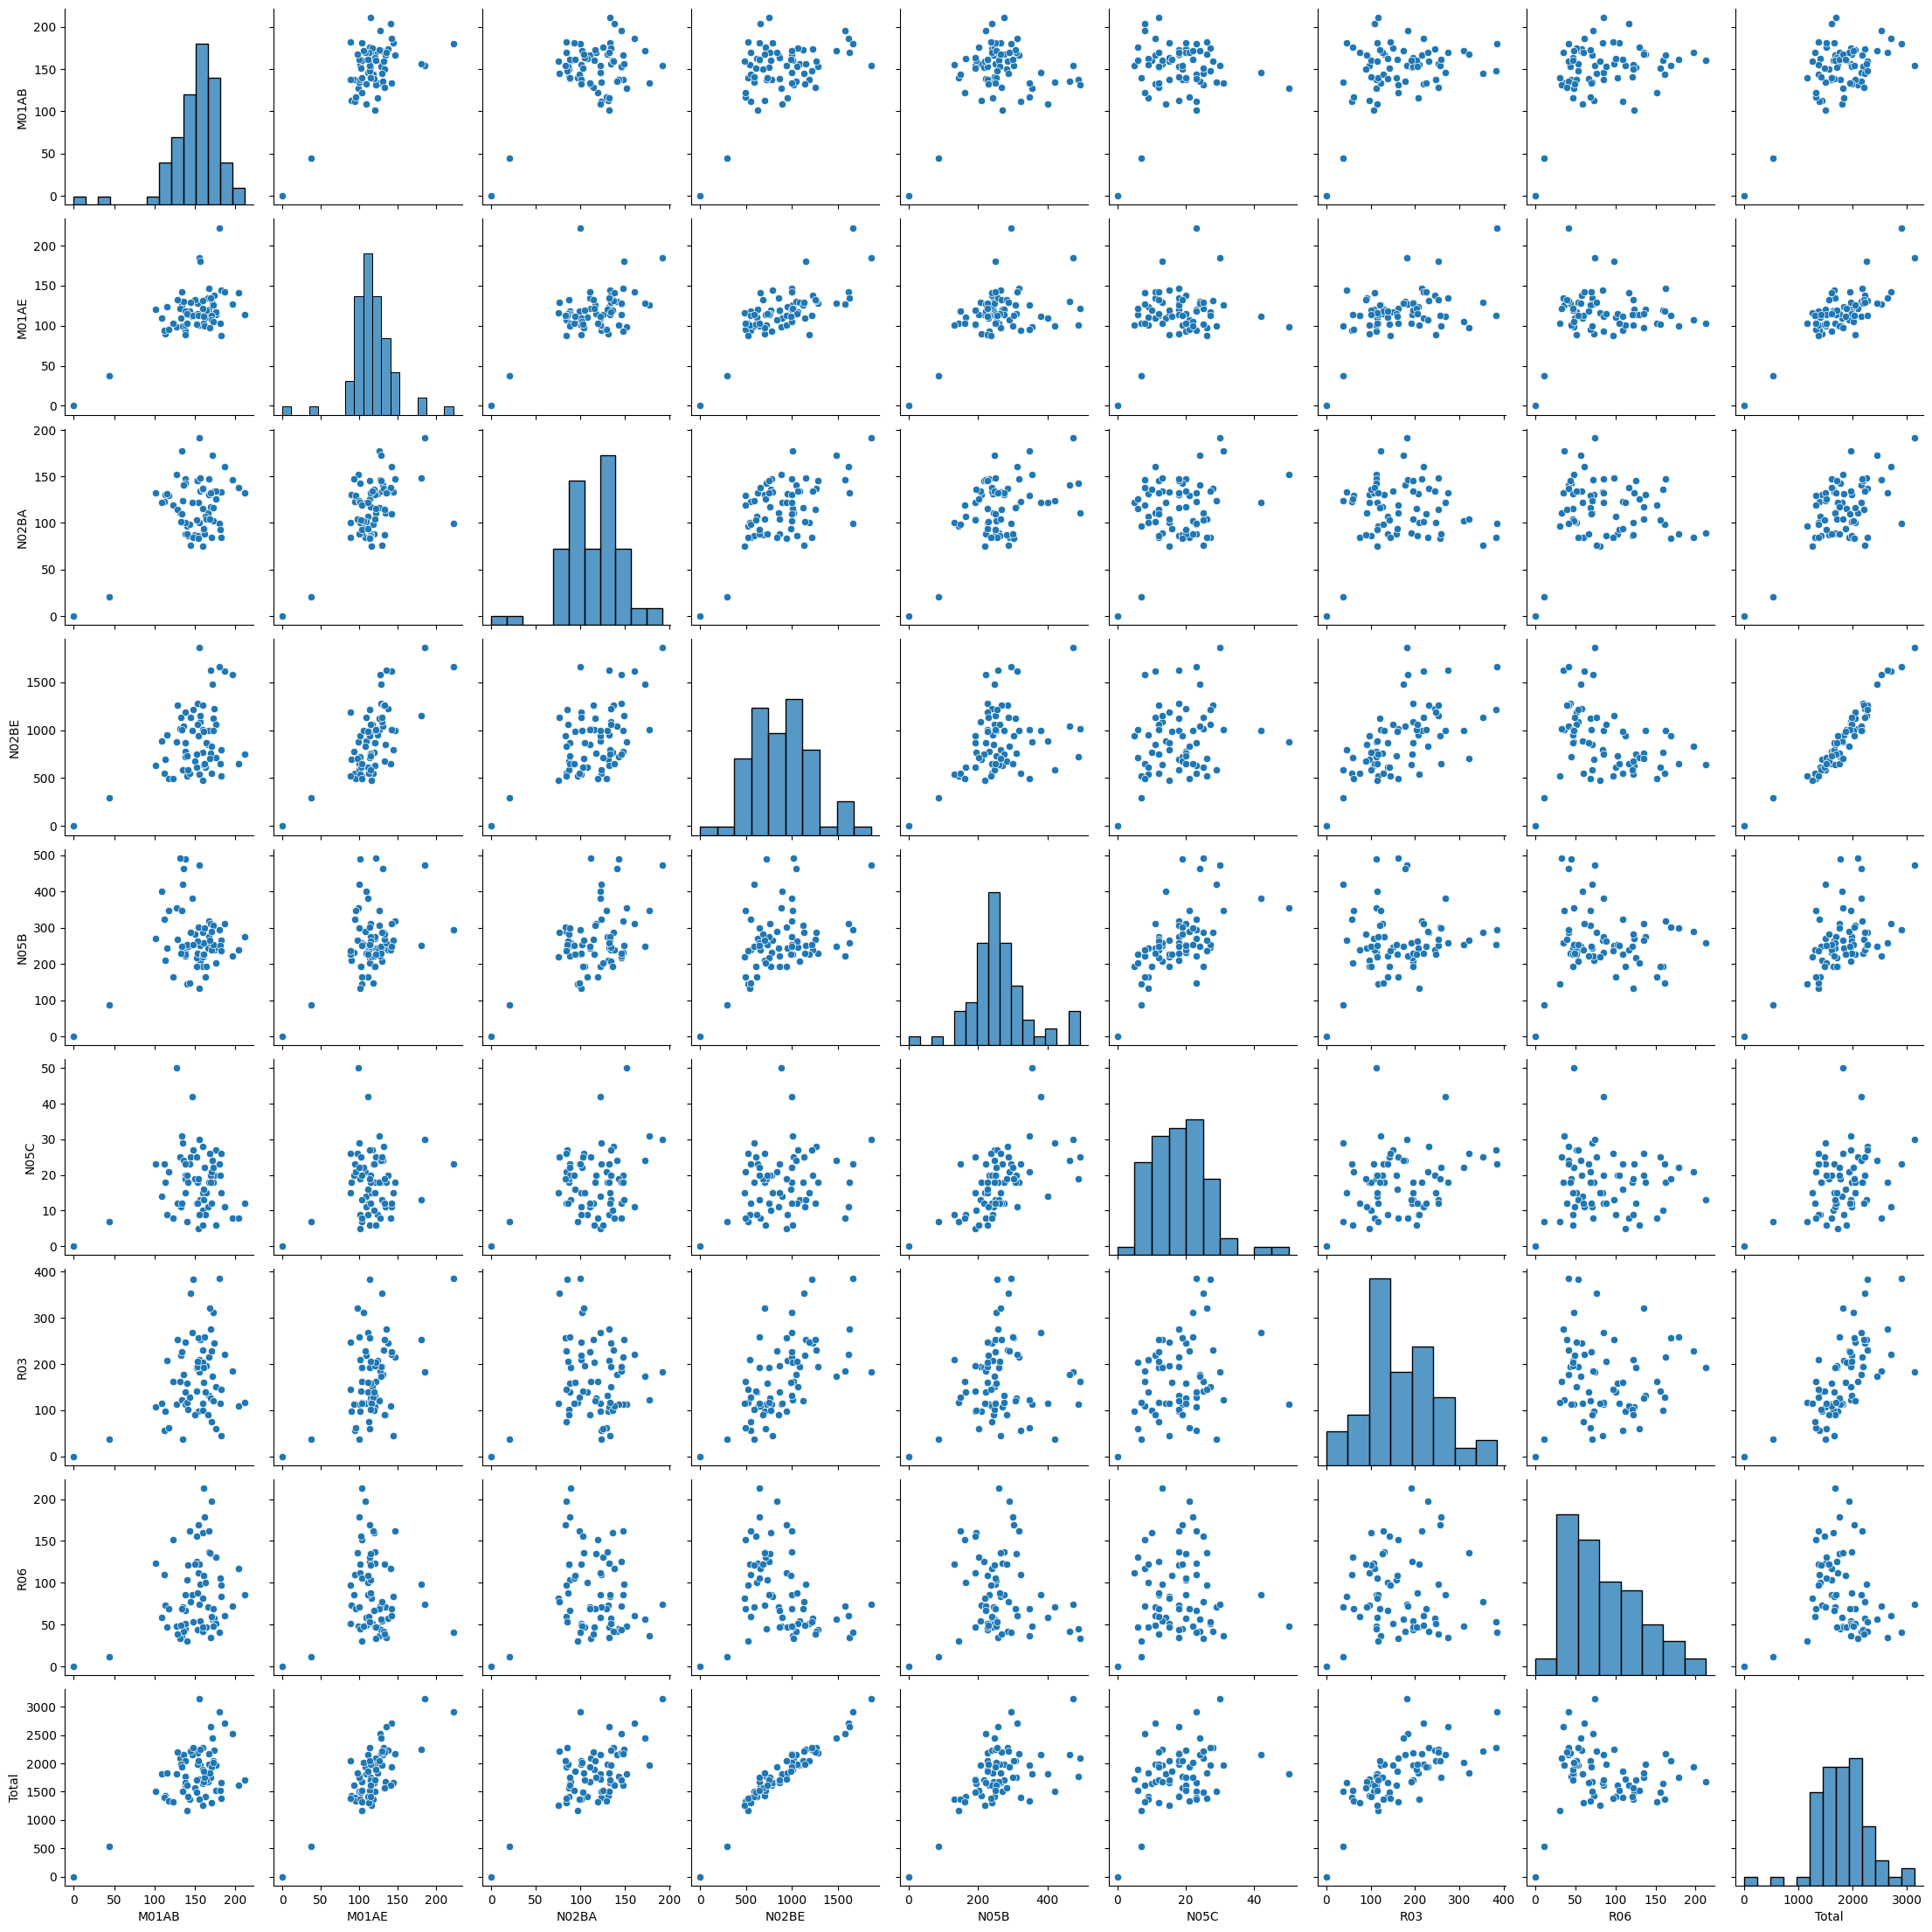

In [ ]:
#MAT DE GR : vrettlp de var num ds DF.
df['Total'] = df['M01AB'] + df['M01AE'] + df['N02BA'] + df['N02BE'] + df['N05B'] + df['N05C'] + df['R03'] + df['R06']

sns.pairplot(data=df)

**2017 ?!**

In [ ]:
mask = (df['datum'] > '2016-12-31') & (df['datum'] < '2018-01-31')
print(df.loc[mask])

         datum   M01AB    M01AE   N02BA     N02BE   N05B  N05C    R03     R06  \
36  2017-01-31    0.00    0.000    0.00     0.000    1.0   0.0    0.0    0.00   
37  2017-02-28  139.69  103.517   97.00   526.350  144.0   7.0  117.0   30.60   
38  2017-03-31  162.85  111.055  107.35   612.500  165.0   9.0  139.0  100.10   
39  2017-04-30  155.61  101.215  100.50   540.200  132.0   9.0  209.0  122.40   
40  2017-05-31  143.66  118.125   98.95   547.940  148.0  23.0  128.0  161.81   
41  2017-06-30  122.33  103.006  119.60   496.100  163.0   8.0  163.0  151.90   
42  2017-07-31  159.67  116.206   75.20   479.350  219.0  15.0  115.0   81.10   
43  2017-08-31  170.15  112.470   84.40   549.300  239.0  12.0   75.0   60.10   
44  2017-09-30  138.33  118.711   88.15   863.750  223.0  23.0  139.0   66.90   
45  2017-10-31  137.64   88.737  100.40  1184.350  226.0  15.0  247.0   51.00   
46  2017-11-30  163.85  119.780  104.45   867.899  192.0  15.0  196.0   46.60   
47  2017-12-31  160.01  121.


Nous pouvons observer que la chute soudaine dans le graphique est due à l'absence de ventes (à l'exception d'une seule unité de N05B) enregistrées pendant le mois de janvier 2017.

Selon Lindsley (2017) : "Les statistiques sur les ventes pharmaceutiques mondiales et régionales sont désormais disponibles, et une forte croissance a été observée dans chaque région ainsi qu'au niveau mondial. En 2017, les ventes mondiales de médicaments s'élevaient à [USD]996 milliards (presque [USD]30 milliards de plus que les [USD]968 milliards enregistrés en 2016)".

References:

Lindsley CW. New 2017 Data and Statistics for Pharmaceutical Products. ACS Chem Neurosci. 2018 Jul 18;9(7):1518-1519. doi: 10.1021/acschemneuro.8b00320


**Handling of missing values:**


Nous pouvons calculer les résultats en utilisant les données quotidiennes, hebdomadaires ou horaires. Dans le cadre de ce projet, je vais calculer les valeurs manquantes en utilisant une moyenne.

In [ ]:
mask = (df['datum'] > '2016-12-31') & (df['datum'] < '2018-01-31')
print(df.loc[mask])

         datum   M01AB    M01AE   N02BA     N02BE   N05B  N05C    R03     R06  \
36  2017-01-31    0.00    0.000    0.00     0.000    1.0   0.0    0.0    0.00   
37  2017-02-28  139.69  103.517   97.00   526.350  144.0   7.0  117.0   30.60   
38  2017-03-31  162.85  111.055  107.35   612.500  165.0   9.0  139.0  100.10   
39  2017-04-30  155.61  101.215  100.50   540.200  132.0   9.0  209.0  122.40   
40  2017-05-31  143.66  118.125   98.95   547.940  148.0  23.0  128.0  161.81   
41  2017-06-30  122.33  103.006  119.60   496.100  163.0   8.0  163.0  151.90   
42  2017-07-31  159.67  116.206   75.20   479.350  219.0  15.0  115.0   81.10   
43  2017-08-31  170.15  112.470   84.40   549.300  239.0  12.0   75.0   60.10   
44  2017-09-30  138.33  118.711   88.15   863.750  223.0  23.0  139.0   66.90   
45  2017-10-31  137.64   88.737  100.40  1184.350  226.0  15.0  247.0   51.00   
46  2017-11-30  163.85  119.780  104.45   867.899  192.0  15.0  196.0   46.60   
47  2017-12-31  160.01  121.

In [ ]:
jan_mask = df['datum'].str.endswith('01-31')
averages = []
averages = df.loc[jan_mask].reset_index() #pr un nv df propre
averages['Weights'] = [0.2, 0.4, 0.6, 1, 0.6, 0.4] #calculer une moyenne plus représentative. ((1,0)), chq ligne se voit attribuer un poids spécifique

df.loc[36, 'M01AB'] = round(np.average(averages['M01AB'], weights = averages['Weights']), 2) #remp nv moy dans col 36
df.loc[36, 'M01AE'] = round(np.average(averages['M01AE'], weights = averages['Weights']), 2)
df.loc[36, 'N02BA'] = round(np.average(averages['N02BA'], weights = averages['Weights']), 2)
df.loc[36, 'N02BE'] = round(np.average(averages['N02BE'], weights = averages['Weights']), 2)
df.loc[36, 'N05B'] = round(np.average(averages['N05B'], weights = averages['Weights']), 2)
df.loc[36, 'N05C'] = round(np.average(averages['N05C'], weights = averages['Weights']), 2)
df.loc[36, 'R03'] = round(np.average(averages['R03'], weights = averages['Weights']), 2)
df.loc[36, 'R06'] = round(np.average(averages['R06'], weights = averages['Weights']), 2)

print(df.loc[36]) #aff ligne 36 apres mise a jour des moy pond
print(df.loc[mask])

datum                  2017-01-31
M01AB                      104.42
M01AE                       94.88
N02BA                        90.9
N02BE                      882.48
N05B                       206.65
N05C                        15.56
R03                        151.09
R06                          33.3
Time_Stamp    2017-01-31 00:00:00
Total                         1.0
Name: 36, dtype: object
         datum   M01AB    M01AE   N02BA     N02BE    N05B   N05C     R03  \
36  2017-01-31  104.42   94.880   90.90   882.480  206.65  15.56  151.09   
37  2017-02-28  139.69  103.517   97.00   526.350  144.00   7.00  117.00   
38  2017-03-31  162.85  111.055  107.35   612.500  165.00   9.00  139.00   
39  2017-04-30  155.61  101.215  100.50   540.200  132.00   9.00  209.00   
40  2017-05-31  143.66  118.125   98.95   547.940  148.00  23.00  128.00   
41  2017-06-30  122.33  103.006  119.60   496.100  163.00   8.00  163.00   
42  2017-07-31  159.67  116.206   75.20   479.350  219.00  15.00  115.


Ci-dessous, nous allons créer un tableau des "totaux" pour les tables hebdomadaires, journalières et horaires afin d'examiner si les mêmes tendances se reproduisent dans les données collectées.

Je vais également regrouper les catégories selon les classes suivantes :

Classe M
Classe N
Classe R

In [ ]:
#Monthly
df_tm = df
df_tm['M_Total'] = df['M01AB'] + df['M01AE']
df_tm['N_Total'] = df['N02BA'] + df['N02BE'] + df['N05B'] + df['N05C']
df_tm['R_Total'] = df['R03'] + df['R06']
df_tm['Total'] = df_tm['M_Total'] + df_tm['N_Total'] + df_tm['R_Total']
del df_tm['M01AB'], df_tm['M01AE'], df_tm['N02BA'], df_tm['N02BE'], df_tm['N05B'], df_tm['N05C'], df_tm['R03'], df_tm['R06']
df_tm['Time_Stamp'] = pd.to_datetime(df_tm['datum'])
df_tm.index = df_tm['datum']

df_tm

,datum,Time_Stamp,Total,M_Total,N_Total,R_Total
datum,,,,,,
2014-01-31,2014-01-31,2014-01-31,1821.110,226.780,1434.13,160.20
2014-02-28,2014-02-28,2014-02-28,1974.470,259.370,1556.90,158.20
2014-03-31,2014-03-31,2014-03-31,1606.720,230.390,1178.93,197.40
2014-04-30,2014-04-30,2014-04-30,1429.675,202.575,1056.40,170.70
2014-05-31,2014-05-31,2014-05-31,1506.303,221.723,1053.88,230.70
...,...,...,...,...,...,...
2019-06-30,2019-06-30,2019-06-30,1482.407,253.167,931.20,298.04
2019-07-31,2019-07-31,2019-07-31,1517.941,284.541,1013.20,220.20
2019-08-31,2019-08-31,2019-08-31,1377.779,270.179,865.30,242.30


<function matplotlib.pyplot.show(close=None, block=None)>

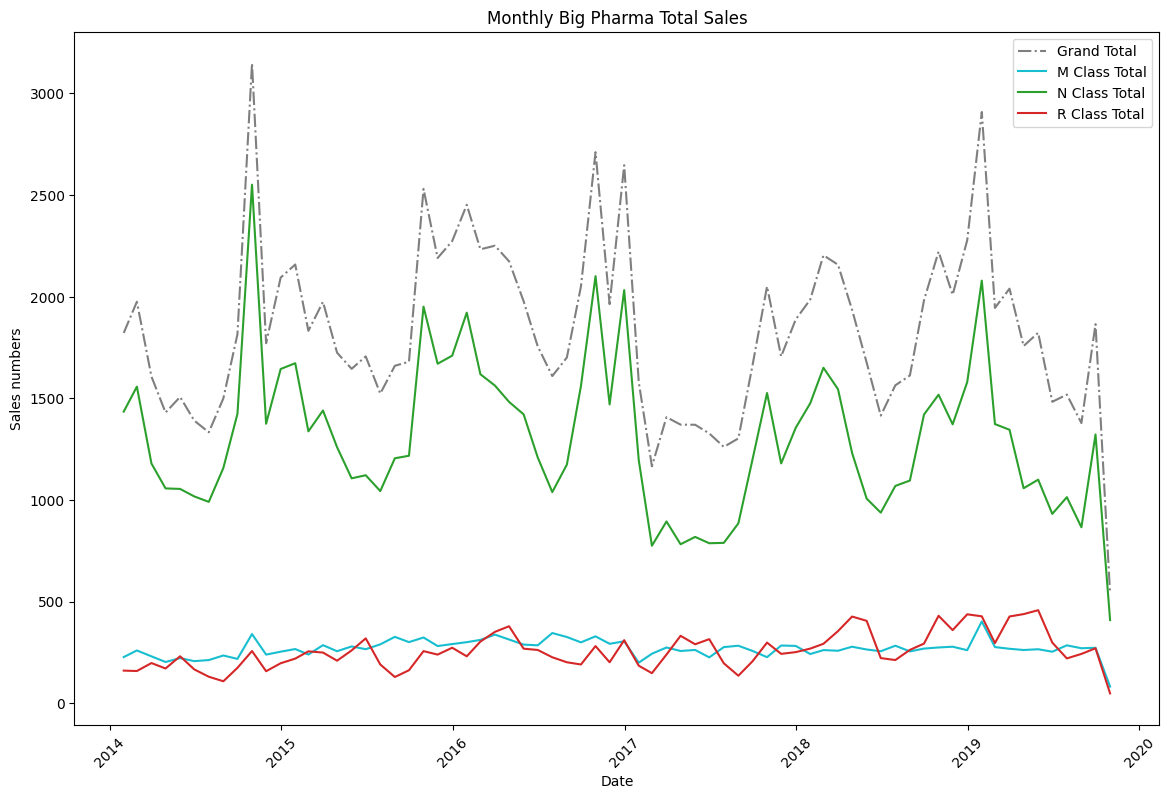

In [ ]:
Date = df_tm['Time_Stamp']
GrTot = df_tm['Total']
M_Tot = df_tm['M_Total']
N_Tot = df_tm['N_Total']
R_Tot = df_tm['R_Total']


plt.rcParams["figure.figsize"] = (14,9)

plt.plot(Date, GrTot, linestyle='-.', color='tab:gray', label='Grand Total')
plt.plot(Date, M_Tot, color='tab:cyan', label='M Class Total')
plt.plot(Date, N_Tot, color='tab:green', label='N Class Total')
plt.plot(Date, R_Tot, color='tab:red', label='R Class Total')


plt.legend()
plt.title('Monthly Big Pharma Total Sales')
plt.xlabel('Date')
plt.ylabel('Sales numbers')
plt.xticks(rotation=45)

plt.show

In [ ]:
#Weekly

df_tw = pd.read_csv('/content/pharma-sales-data/salesweekly.csv')
df_tw['M_Total'] = df_tw['M01AB'] + df_tw['M01AE']
df_tw['N_Total'] = df_tw['N02BA'] + df_tw['N02BE'] + df_tw['N05B'] + df_tw['N05C']
df_tw['R_Total'] = df_tw['R03'] + df_tw['R06']
df_tw['Total'] = df_tw['M_Total'] + df_tw['N_Total'] + df_tw['R_Total']
del df_tw['M01AB'], df_tw['M01AE'], df_tw['N02BA'], df_tw['N02BE'], df_tw['N05B'], df_tw['N05C'], df_tw['R03'], df_tw['R06']
df_tw['Time_Stamp'] = pd.to_datetime(df_tw['datum'])
df_tw.index = df_tw['datum']

df_tw

,datum,M_Total,N_Total,R_Total,Total,Time_Stamp
datum,,,,,,
1/5/2014,1/5/2014,25.670,248.250,39.000000,312.920000,2014-01-05
1/12/2014,1/12/2014,42.010,321.600,28.200000,391.810000,2014-01-12
1/19/2014,1/19/2014,57.010,352.300,41.000000,450.310000,2014-01-19
1/26/2014,1/26/2014,66.370,299.100,33.000000,398.470000,2014-01-26
2/2/2014,2/2/2014,54.370,276.580,41.000000,371.950000,2014-02-02
...,...,...,...,...,...,...
9/15/2019,9/15/2019,66.487,270.225,60.500000,397.212000,2019-09-15
9/22/2019,9/22/2019,72.236,306.850,47.000000,426.086000,2019-09-22
9/29/2019,9/29/2019,56.508,425.500,63.516667,545.524667,2019-09-29


<function matplotlib.pyplot.show(close=None, block=None)>

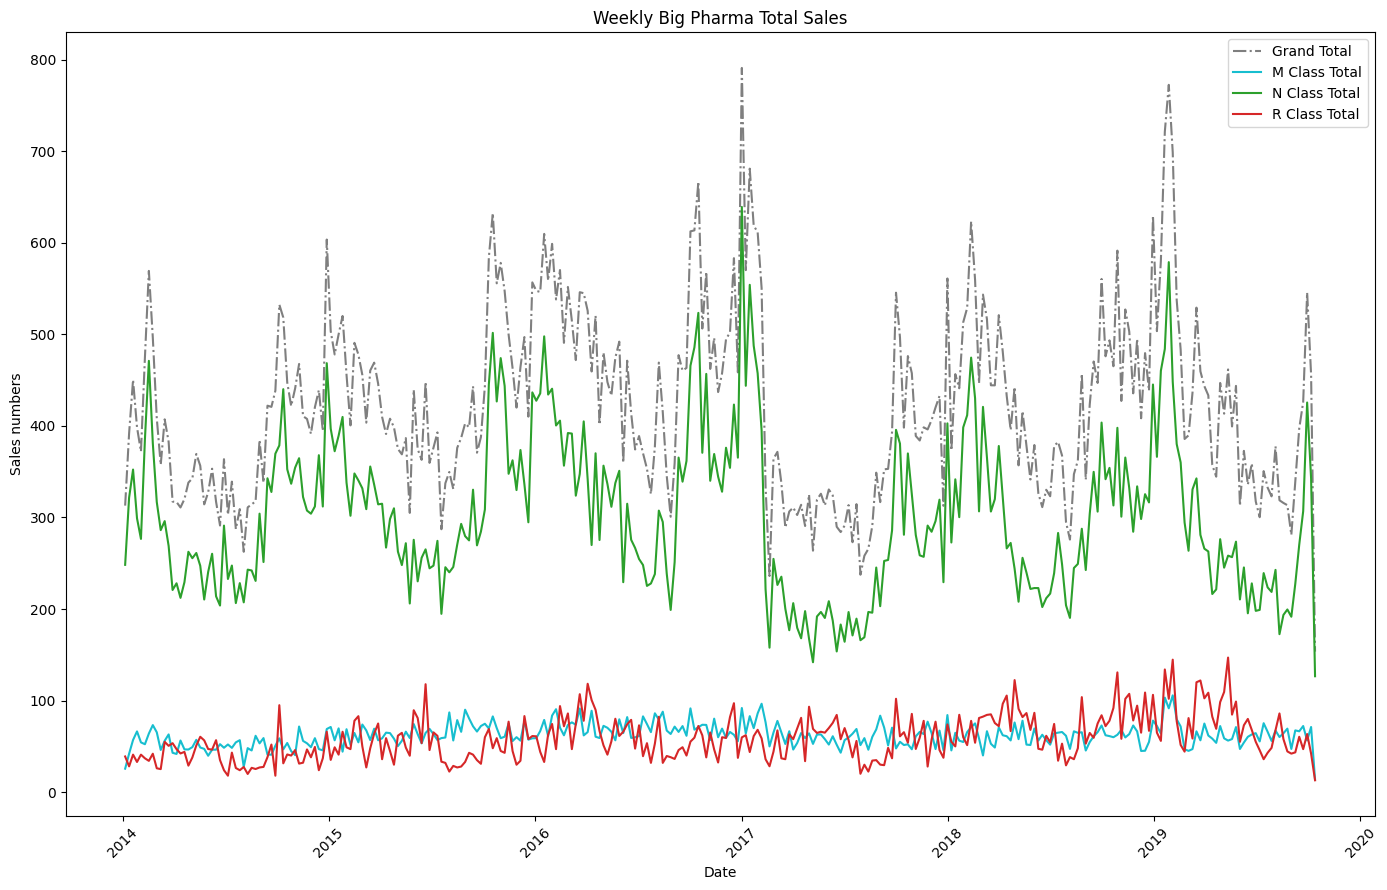

In [ ]:
Date = df_tw['Time_Stamp']
GrTot = df_tw['Total']
M_Tot = df_tw['M_Total']
N_Tot = df_tw['N_Total']
R_Tot = df_tw['R_Total']


plt.rcParams["figure.figsize"] = (14,9)

plt.plot(Date, GrTot, linestyle='-.', color='tab:gray', label='Grand Total')
plt.plot(Date, M_Tot, color='tab:cyan', label='M Class Total')
plt.plot(Date, N_Tot, color='tab:green', label='N Class Total')
plt.plot(Date, R_Tot, color='tab:red', label='R Class Total')


plt.legend()
plt.title('Weekly Big Pharma Total Sales')
plt.xlabel('Date')
plt.ylabel('Sales numbers')
plt.xticks(rotation=45)

plt.tight_layout()

plt.show

In [ ]:
#Daily

df_td = pd.read_csv('/content/pharma-sales-data/salesdaily.csv')
df_td['M_Total'] = df_td['M01AB'] + df_td['M01AE']
df_td['N_Total'] = df_td['N02BA'] + df_td['N02BE'] + df_td['N05B'] + df_td['N05C']
df_td['R_Total'] = df_td['R03'] + df_td['R06']
df_td['Total'] = df_td['M_Total'] + df_td['N_Total'] + df_td['R_Total']
del df_td['M01AB'], df_td['M01AE'], df_td['N02BA'], df_td['N02BE'], df_td['N05B'], df_td['N05C'], df_td['R03'], df_td['R06']
df_td['Time_Stamp'] = pd.to_datetime(df_td['datum'])
df_td.index = df_td['datum']

df_td

,datum,Year,Month,Hour,Weekday Name,M_Total,N_Total,R_Total,Total,Time_Stamp
datum,,,,,,,,,,
1/2/2014,1/2/2014,2014,1,248,Thursday,3.670,42.80,2.00,48.470,2014-01-02
1/3/2014,1/3/2014,2014,1,276,Friday,12.000,71.00,24.00,107.000,2014-01-03
1/4/2014,1/4/2014,2014,1,276,Saturday,3.000,78.35,10.00,91.350,2014-01-04
1/5/2014,1/5/2014,2014,1,276,Sunday,7.000,56.10,3.00,66.100,2014-01-05
1/6/2014,1/6/2014,2014,1,276,Monday,6.000,44.20,8.00,58.200,2014-01-06
...,...,...,...,...,...,...,...,...,...,...
10/4/2019,10/4/2019,2019,10,276,Friday,13.023,37.70,2.00,52.723,2019-10-04
10/5/2019,10/5/2019,2019,10,276,Saturday,8.850,38.40,0.33,47.580,2019-10-05
10/6/2019,10/6/2019,2019,10,276,Sunday,15.690,42.60,9.20,67.490,2019-10-06


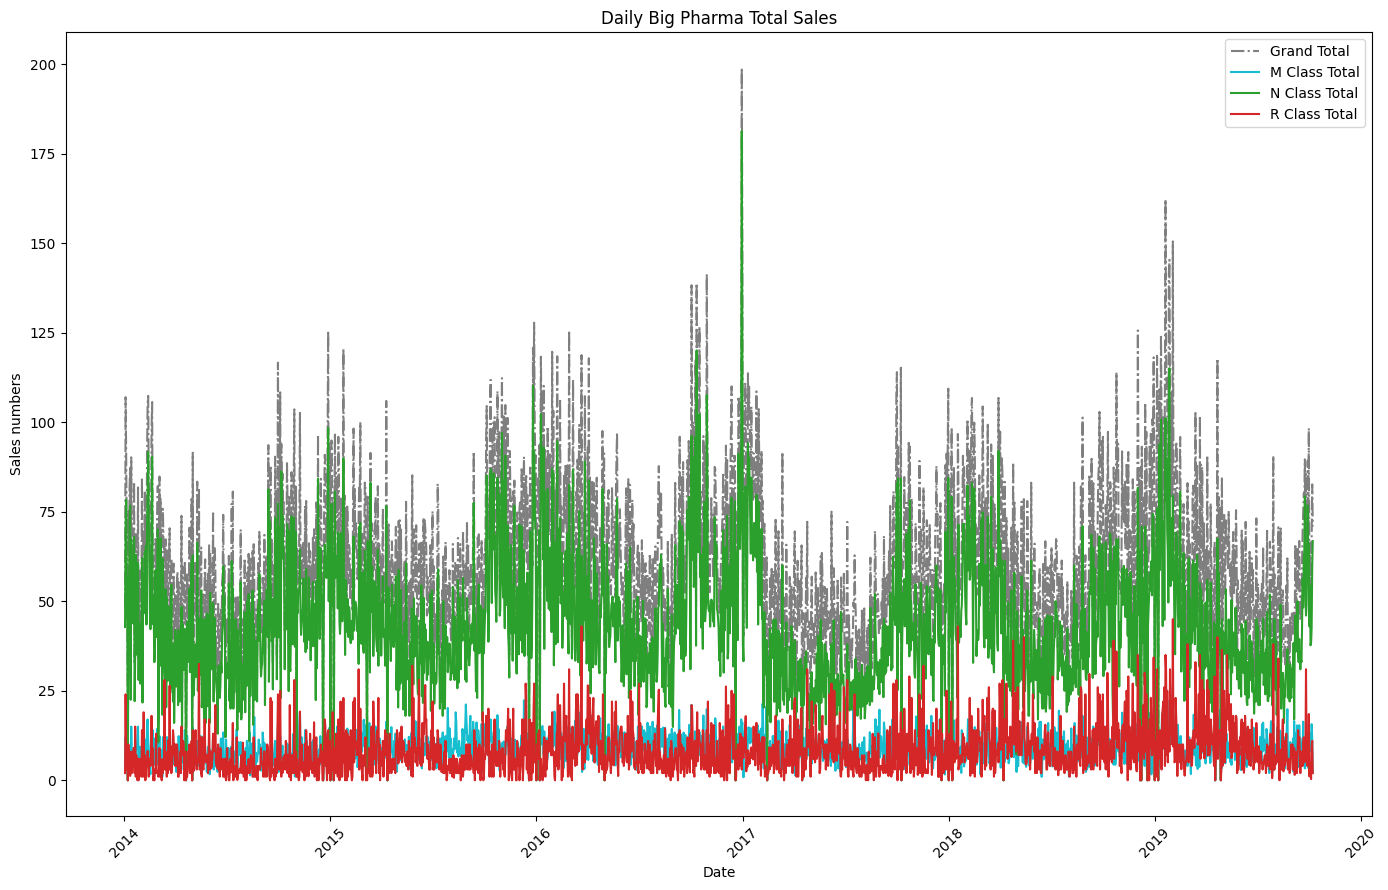

In [ ]:
Date = df_td['Time_Stamp']
GrTot = df_td['Total']
M_Tot = df_td['M_Total']
N_Tot = df_td['N_Total']
R_Tot = df_td['R_Total']


plt.rcParams["figure.figsize"] = (14,9)

plt.plot(Date, GrTot, linestyle='-.', color='tab:gray', label='Grand Total')
plt.plot(Date, M_Tot, color='tab:cyan', label='M Class Total')
plt.plot(Date, N_Tot, color='tab:green', label='N Class Total')
plt.plot(Date, R_Tot, color='tab:red', label='R Class Total')


plt.legend()
plt.title('Daily Big Pharma Total Sales')
plt.xlabel('Date')
plt.ylabel('Sales numbers')
plt.xticks(rotation=45)

plt.tight_layout()


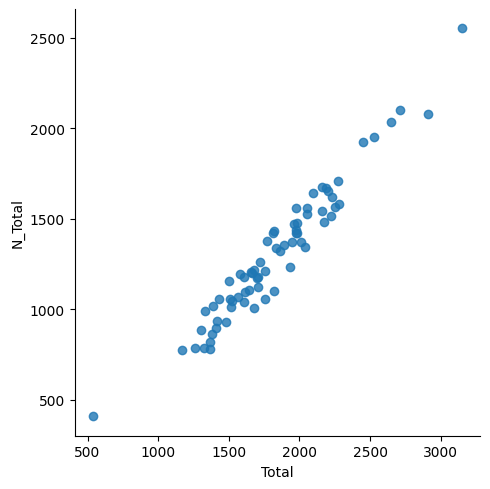

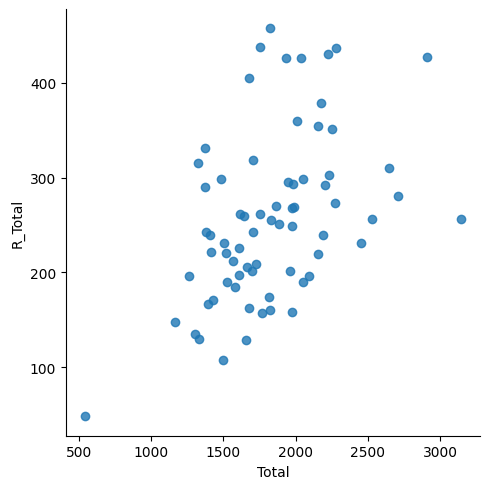

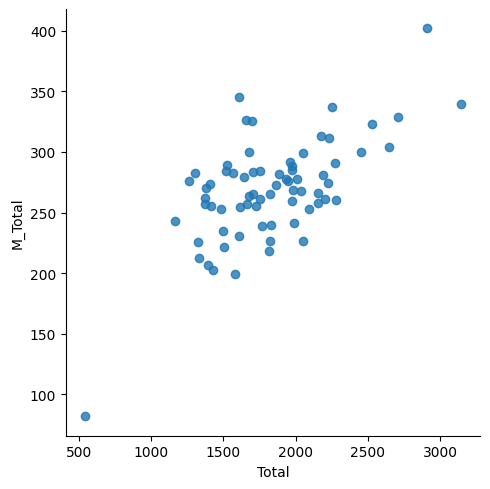

In [ ]:
sns.lmplot(data = df, x = 'Total', y = 'N_Total', fit_reg = False)
sns.lmplot(data = df, x = 'Total', y = 'R_Total', fit_reg = False)
sns.lmplot(data = df, x = 'Total', y = 'M_Total', fit_reg = False)

**conclusion** :
mon projet analyse les données de ventes pharmaceutiques pour identifier les tendances et les facteurs influençant les ventes. En appliquant des modèles de prévision, il aide à anticiper les tendances futures et à guider des décisions stratégiques afin d'optimiser les performances commerciales et améliorer les ventes globales.